In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

m = loadmat("../data/input/SC_D_AAL424.mat")
SC, D, coords = m["SC"], m["D"], m["coords"]

print(m.keys())
for name, a in [("SC", SC), ("D", D), ("coords", coords)]:
    print(name, a.shape, a.dtype, "min", round(a.min(), 3), "max", round(a.max(), 3), "mean", round(a.mean(), 3))
SC

dict_keys(['__header__', '__version__', '__globals__', 'SC', 'D', 'coords'])
SC (424, 424) float64 min 0.0 max 0.996 mean 0.051
D (424, 424) float64 min 0.0 max 158.458 mean 76.956
coords (424, 3) float64 min -88.549 max 71.176 mean -2.373


array([[0.00000000e+00, 1.58600789e-01, 3.73507319e-01, ...,
        1.59729108e-03, 3.98777227e-02, 6.52939940e-03],
       [1.58600789e-01, 0.00000000e+00, 1.65776843e-01, ...,
        4.49809323e-05, 4.55367518e-03, 5.41102355e-03],
       [3.73507319e-01, 1.65776843e-01, 0.00000000e+00, ...,
        2.03118510e-05, 1.14854869e-03, 1.35347458e-04],
       ...,
       [1.59729108e-03, 4.49809323e-05, 2.03118510e-05, ...,
        0.00000000e+00, 4.44134162e-01, 1.16173327e-01],
       [3.98777227e-02, 4.55367518e-03, 1.14854869e-03, ...,
        4.44134162e-01, 0.00000000e+00, 4.64859463e-01],
       [6.52939940e-03, 5.41102355e-03, 1.35347458e-04, ...,
        1.16173327e-01, 4.64859463e-01, 0.00000000e+00]])

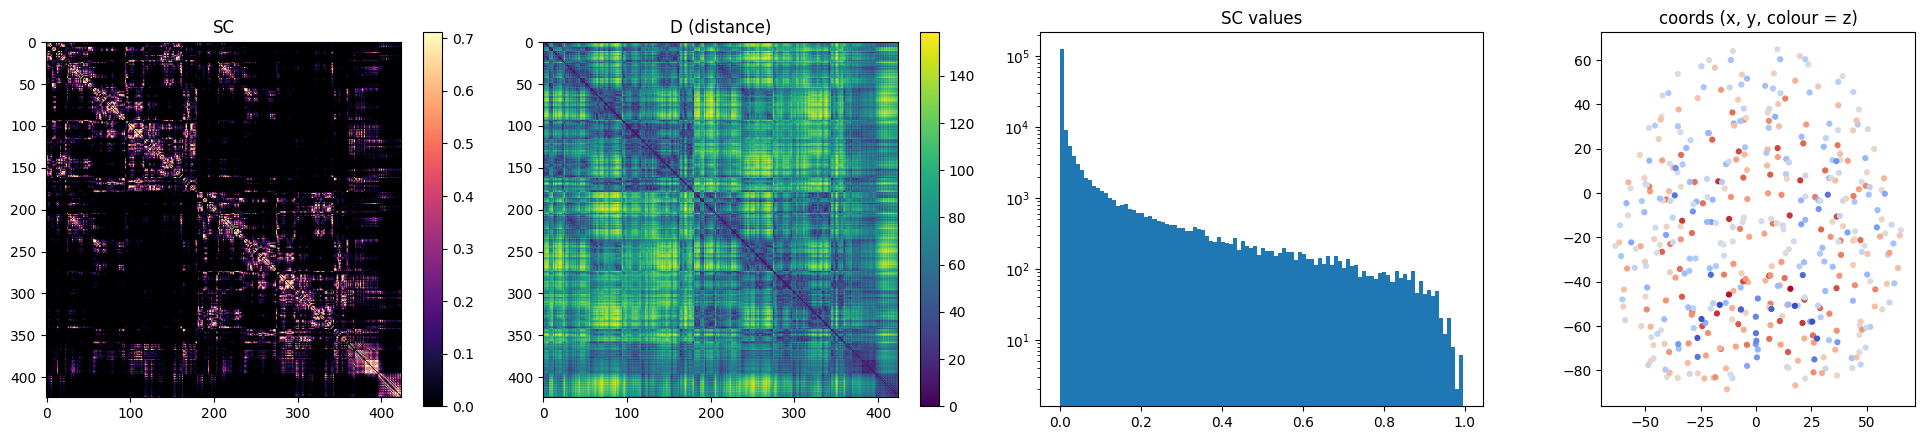

In [2]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4.5))

im = ax[0].imshow(SC, cmap="magma", vmax=np.percentile(SC, 99))
ax[0].set_title("SC"); fig.colorbar(im, ax=ax[0])

im = ax[1].imshow(D, cmap="viridis")
ax[1].set_title("D (distance)"); fig.colorbar(im, ax=ax[1])

ax[2].hist(SC[~np.eye(len(SC), dtype=bool)], bins=100)
ax[2].set_yscale("log"); ax[2].set_title("SC values")

ax[3].scatter(coords[:, 0], coords[:, 1], c=coords[:, 2], s=12, cmap="coolwarm")
ax[3].set_title("coords (x, y, colour = z)"); ax[3].set_aspect("equal")

plt.tight_layout(); plt.show()